In [1]:
print("Hello SVM!")

Hello SVM!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Load bộ dữ liệu Iris
iris = load_iris()

# Chuyển dữ liệu thành DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Thêm cột tên loài hoa
df["target"] = iris.target

# Hiển thị 5 dòng đầu tiên
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
# Kiểm tra kích thước dữ liệu
print("Số lượng mẫu:", df.shape[0])
print("Số lượng đặc trưng:", df.shape[1] - 1)

# Kiểm tra số lượng từng loại hoa
print("\nSố lượng từng loại hoa:")
print(df["target"].value_counts())

Số lượng mẫu: 150
Số lượng đặc trưng: 4

Số lượng từng loại hoa:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [5]:
# Tạo tên cho 3 loại hoa
target_names = iris.target_names

# Hiển thị tên các loại hoa
print("Các loại hoa:")
for i, name in enumerate(target_names):
    print(i, "=", name)

Các loại hoa:
0 = setosa
1 = versicolor
2 = virginica


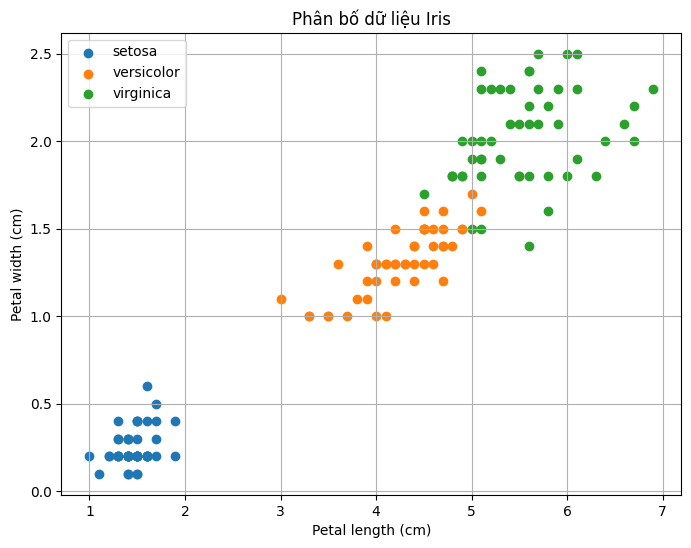

In [6]:
# Vẽ biểu đồ dữ liệu Iris
plt.figure(figsize=(8, 6))

for i, name in enumerate(target_names):
    subset = df[df["target"] == i]
    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=name
    )

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Phân bố dữ liệu Iris")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# Tách đặc trưng (X) và nhãn (y)
X = iris.data
y = iris.target

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Kiểm tra số lượng dữ liệu
print("Số mẫu dùng để huấn luyện:", len(X_train))
print("Số mẫu dùng để kiểm tra:", len(X_test))

Số mẫu dùng để huấn luyện: 120
Số mẫu dùng để kiểm tra: 30


In [8]:
# Khởi tạo bộ chuẩn hóa
scaler = StandardScaler()

# Học cách chuẩn hóa từ tập huấn luyện
X_train_scaled = scaler.fit_transform(X_train)

# Áp dụng cách chuẩn hóa cho tập kiểm tra
X_test_scaled = scaler.transform(X_test)

print("Đã chuẩn hóa dữ liệu thành công!")

Đã chuẩn hóa dữ liệu thành công!


In [9]:
# Tạo mô hình SVM
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale")

# Huấn luyện mô hình bằng dữ liệu Training
svm_model.fit(X_train_scaled, y_train)

print("Đã huấn luyện mô hình SVM thành công!")

Đã huấn luyện mô hình SVM thành công!


In [10]:
# Dự đoán trên tập kiểm tra
y_pred = svm_model.predict(X_test_scaled)

# Hiển thị kết quả dự đoán
print("Kết quả dự đoán:")
print(y_pred)

Kết quả dự đoán:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [11]:
# Tính độ chính xác
accuracy = accuracy_score(y_test, y_pred)

print("Độ chính xác của mô hình SVM:", accuracy)
print("Độ chính xác (%):", accuracy * 100)

Độ chính xác của mô hình SVM: 0.9666666666666667
Độ chính xác (%): 96.66666666666667


In [12]:
# Báo cáo đánh giá chi tiết mô hình
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=target_names
))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Ma trận nhầm lẫn:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


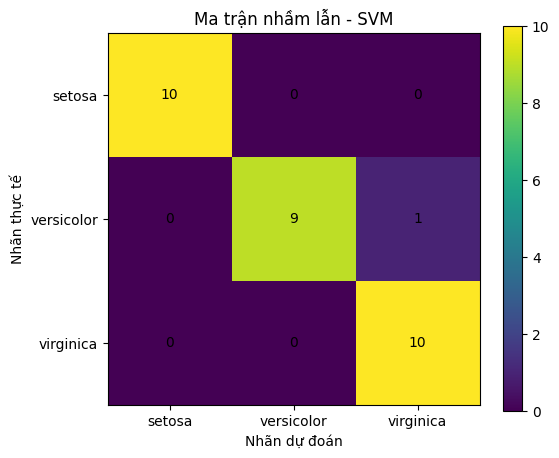

In [13]:
# Tạo ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)

print("Ma trận nhầm lẫn:")
print(cm)

# Vẽ ma trận nhầm lẫn
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Ma trận nhầm lẫn - SVM")
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")

plt.xticks(range(3), target_names)
plt.yticks(range(3), target_names)

# Hiển thị số lượng trên từng ô
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [14]:
# Dự đoán một mẫu hoa mới

# Thông số của một bông hoa mới:
# sepal length, sepal width, petal length, petal width
new_flower = [[5.1, 3.5, 1.4, 0.2]]

# Chuẩn hóa dữ liệu mới
new_flower_scaled = scaler.transform(new_flower)

# Dự đoán
prediction = svm_model.predict(new_flower_scaled)

# Hiển thị kết quả
print("Kết quả dự đoán:", target_names[prediction[0]])

Kết quả dự đoán: setosa


## Kết luận

Mô hình Support Vector Machine (SVM) được áp dụng để phân loại hoa Iris thành 3 lớp: Setosa, Versicolor và Virginica.

Dữ liệu gồm 150 mẫu với 4 đặc trưng. Dữ liệu được chia thành 80% tập huấn luyện và 20% tập kiểm tra, sau đó được chuẩn hóa trước khi đưa vào mô hình SVM.

Kết quả thực nghiệm cho thấy mô hình đạt độ chính xác 96.67% trên tập kiểm tra. Ma trận nhầm lẫn cho thấy mô hình phân loại đúng 29/30 mẫu, chỉ nhầm 1 mẫu Versicolor thành Virginica.

Qua đó, SVM cho thấy khả năng phân loại dữ liệu Iris tốt và phù hợp với bài toán phân loại nhiều lớp.